In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


Parameters loaded.
GP Solver converged in 6 iterations.
Plot saved to 'comparison_with_pnl.png'

Final Cumulative PnL:
DDRL: 15.3307
GP:   14.9460


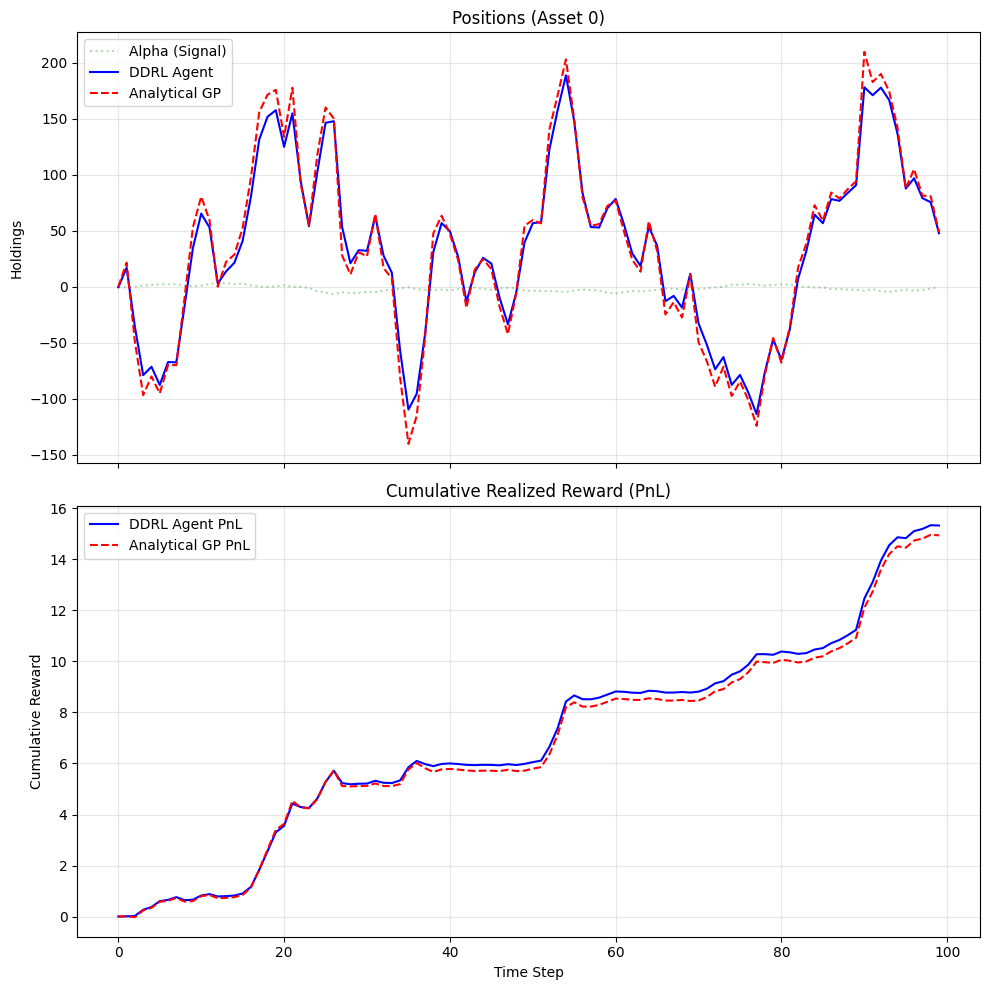

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. Parameter Loading
# ==========================================
def load_parameters(json_path="debug_params.json"):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Could not find {json_path}. Run the export step first.")
        
    with open(json_path, "r") as f:
        data = json.load(f)
    
    matrices = data["matrices"]
    scalars = data["scalars"]
    
    params = {
        "A": np.array(matrices["alpha_weights"]),
        "B": np.array(matrices["return_weights"]),
        "Sigma": np.array(matrices["sigma"]),
        "Omega": np.array(matrices["omega"]),
        "Lambda": np.array(matrices["cost_lambda"]),
        "gamma": float(scalars["trader_risk"]),
        "num_assets": int(scalars["num_assets"]),
        "num_alphas": int(scalars["num_alphas"])
    }
    return params

# ==========================================
# 2. GP Solver (Riccati)
# ==========================================
def solve_gp_policy(params, max_iter=1000, tol=1e-6):
    A = params["A"]
    B = params["B"]
    Sigma = params["Sigma"]
    Lambda = params["Lambda"]
    gamma = params["gamma"]
    
    n_alpha = A.shape[0]
    n_asset = Sigma.shape[0]
    
    E_aa = np.zeros((n_alpha, n_alpha))
    E_aw = np.zeros((n_alpha, n_asset))
    E_ww = np.zeros((n_asset, n_asset))
    
    for i in range(max_iter):
        E_aa_old = E_aa.copy()
        
        # M = Inverse of quadratic penalty on w_t
        # Note: If your Env uses Cost = 1.0 * dw' Lambda dw, then effectively
        # the GP "belief" about cost should match. 
        # Standard GP assumes Cost = 0.5 * dw' Lambda dw.
        # If the agent is beating GP, it's often because GP assumes 0.5 but Env charges 1.0.
        M = np.linalg.inv(gamma * Sigma + Lambda + E_ww)
        
        K_alpha = M @ (B + E_aw.T @ A)
        K_w = M @ Lambda
        
        E_ww = Lambda - Lambda @ M @ Lambda
        E_aw = (B.T + A.T @ E_aw) @ M @ Lambda
        
        # E_aa update (optional for policy, needed for value)
        # E_aa_new = A' E_aa A - ... (omitted for brevity as we just need K)
        
        if i > 5 and np.max(np.abs(E_ww - (Lambda - Lambda @ M @ Lambda))) < tol:
            break
            
    print(f"GP Solver converged in {i} iterations.")
    return K_alpha, K_w

# ==========================================
# 3. PnL Calculation (The New Function)
# ==========================================
def calculate_realized_pnl(df, params, suffix):
    """
    Calculates the step-by-step reward (Signal - Risk - Cost) for a specific agent/suffix.
    Replicates the logic in MarketEnv.reward exactly.
    """
    T = len(df)
    n_assets = params["num_assets"]
    n_alphas = params["num_alphas"]
    
    # Matrices
    B = params["B"]       # Return Weights
    Sigma = params["Sigma"] # Risk Matrix
    Lambda = params["Lambda"] # Cost Matrix
    gamma = params["gamma"]
    
    # Extract arrays
    # 1. Alphas
    alpha_cols = [c for c in df.columns if "alpha" in c]
    alpha_t = df[alpha_cols].values # (T, n_alphas)
    
    # 2. Positions (w_t)
    pos_cols = [f"pos_{suffix}_{i}" for i in range(n_assets)]
    w_t = df[pos_cols].values # (T, n_assets)
    
    # 3. Previous Positions (w_{t-1}) for Cost
    # Shift w_t down by 1, fill first with 0
    w_prev = np.vstack([np.zeros((1, n_assets)), w_t[:-1, :]])
    dw_t = w_t - w_prev
    
    # --- Vectorized Calculation ---
    
    # 1. Signal: w_t' B alpha_t
    # (T, n_assets) @ (n_assets, n_alphas) @ (n_alphas, T)^T -> (T,)
    # Easier: B_alpha = alpha @ B.T -> (T, n_assets). Then dot with w.
    expected_returns = alpha_t @ B.T
    signal_term = np.sum(w_t * expected_returns, axis=1)
    
    # 2. Risk: 0.5 * gamma * w_t' Sigma w_t
    # calc w @ Sigma per row
    w_sigma = w_t @ Sigma
    risk_term = 0.5 * gamma * np.sum(w_t * w_sigma, axis=1)
    
    # 3. Cost: dw_t' Lambda dw_t
    # CHECK: Does Env use 0.5 or 1.0? 
    # Based on your upload, Env used: (w-lw) @ Lambda @ (w-lw).T (No 0.5)
    dw_lambda = dw_t @ Lambda
    cost_term = np.sum(dw_t * dw_lambda, axis=1)
    
    # If your environment strictly had 0.5, uncomment below:
    # cost_term = 0.5 * cost_term 
    
    rewards = signal_term - risk_term - cost_term
    cumulative_rewards = np.cumsum(rewards)
    
    return cumulative_rewards

# ==========================================
# 4. Simulation & Plotting
# ==========================================
def main():
    try:
        params = load_parameters()
        print("Parameters loaded.")
    except Exception as e:
        print(e)
        return

    # A. Solve GP
    K_alpha, K_w = solve_gp_policy(params)

    # B. Load Trajectory and Add GP Positions
    if not os.path.exists("debug_trajectory.csv"):
        print("debug_trajectory.csv not found.")
        return
        
    df = pd.read_csv("debug_trajectory.csv")
    
    # Simulate GP on this specific trajectory
    alpha_cols = [c for c in df.columns if "alpha" in c]
    alphas = df[alpha_cols].values
    T = len(df)
    w_gp = np.zeros((T, params["num_assets"]))
    w_prev = np.zeros(params["num_assets"])
    
    for t in range(T):
        w_t = K_alpha @ alphas[t] + K_w @ w_prev
        w_gp[t] = w_t
        w_prev = w_t
        
    # Save GP positions to DF so the PnL function can find them
    for i in range(params["num_assets"]):
        df[f"pos_gp_{i}"] = w_gp[:, i]
        # Rename 'pos_new' to 'pos_ddrl' for consistency in the helper
        df[f"pos_ddrl_{i}"] = df[f"pos_new_{i}"]

    # C. Calculate Rewards
    cum_reward_ddrl = calculate_realized_pnl(df, params, suffix="ddrl")
    cum_reward_gp = calculate_realized_pnl(df, params, suffix="gp")
    
    # D. Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    
    # Plot 1: Positions (Asset 0)
    asset_idx = 0
    ax1.plot(df[f"alpha_{asset_idx}"], label="Alpha (Signal)", color="green", alpha=0.3, linestyle=":")
    ax1.plot(df[f"pos_ddrl_{asset_idx}"], label="DDRL Agent", color="blue")
    ax1.plot(df[f"pos_gp_{asset_idx}"], label="Analytical GP", color="red", linestyle="--")
    ax1.set_title(f"Positions (Asset {asset_idx})")
    ax1.set_ylabel("Holdings")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Cumulative PnL
    ax2.plot(cum_reward_ddrl, label="DDRL Agent PnL", color="blue")
    ax2.plot(cum_reward_gp, label="Analytical GP PnL", color="red", linestyle="--")
    ax2.set_title("Cumulative Realized Reward (PnL)")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Cumulative Reward")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("50_horizon_comparison_with_pnl.png")
    print("Plot saved to 'comparison_with_pnl.png'")
    
    # Print final totals
    print(f"\nFinal Cumulative PnL:")
    print(f"DDRL: {cum_reward_ddrl[-1]:.4f}")
    print(f"GP:   {cum_reward_gp[-1]:.4f}")

if __name__ == "__main__":
    main()